# Quantum Teleportation Protocol

In [2]:
from qiskit import transpile
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, state_fidelity, DensityMatrix, partial_trace
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

import numpy as np
from IPython.display import display
from typing import Dict

In [187]:
def random_single_qubit_state(seed=None):
    rng = np.random.default_rng(seed)

    theta = rng.uniform(0, np.pi)
    phi = rng.uniform(0, 2 * np.pi)

    state = np.array([
        np.cos(theta / 2),
        np.exp(1j * phi) * np.sin(theta / 2)
    ], dtype=complex)

    return Statevector(state)

In [188]:
def teleportation_fidelity(qc, original_state, bob_qubit=2):
    if not isinstance(original_state, Statevector):
        original_state = Statevector(original_state)

    qc_clean = QuantumCircuit(qc.num_qubits)

    for operation, qubits, clbits in qc.data:
        if operation.name == "measure":
            continue

        if hasattr(operation, "condition") and operation.condition is not None:
            continue

        qc_clean.append(operation, qubits)

    qc_clean.cx(1, bob_qubit)
    qc_clean.cz(0, bob_qubit)

    final_sv = Statevector.from_instruction(qc_clean)

    final_dm = DensityMatrix(final_sv)

    trace_out = [i for i in range(qc.num_qubits) if i != bob_qubit]
    bob_dm = partial_trace(final_dm, trace_out)

    fidelity = state_fidelity(original_state, bob_dm)

    return fidelity

In [189]:
def teleportation_fidelity_noisy(qc, original_state, backend, bob_qubit=2):
    if not isinstance(original_state, Statevector):
        original_state = Statevector(original_state)

    qc_nom = qc.remove_final_measurements(inplace=False)

    qc_decomp = transpile(qc_nom, backend)

    qc_decomp.save_density_matrix(qubits=[bob_qubit])

    result = backend.run(qc_decomp).result()

    bob_dm = DensityMatrix(result.data(0)["density_matrix"])

    return state_fidelity(original_state, bob_dm)

In [190]:
def teleportation(state):
    qc = QuantumCircuit(3, 2)

    # State to teleport
    qc.prepare_state(state, qubits=[0])

    qc.barrier()

    # Create Bell pair
    qc.h(1)
    qc.cx(1, 2)
    qc.barrier()

    # Alice operations
    qc.cx(0, 1)
    qc.h(0)
    qc.barrier()

    qc.measure([0,1], [0,1])
    qc.barrier()
    
    # Bob correction
    with qc.if_test((qc.clbits[1], True)):
        qc.x(2)

    with qc.if_test((qc.clbits[0], True)):
        qc.z(2)

    return qc

<IPython.core.display.Latex object>

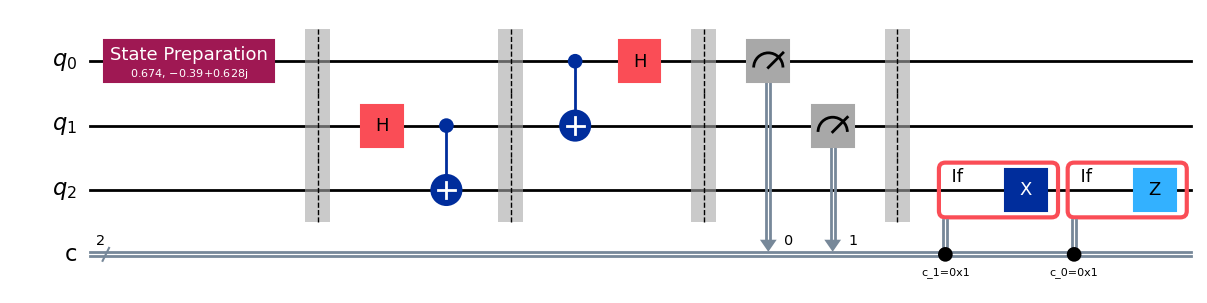

In [191]:
state = random_single_qubit_state()
display(state.draw("latex", prefix="|ψ⟩ = "))

qc = teleportation(state)
qc.draw('mpl')

In [192]:
ideal_sim = AerSimulator()
noisy_sim = FakeSherbrooke()

In [193]:
fid_ideal = teleportation_fidelity(qc, state)
print("Teleportation fidelity in ideal sim:", fid_ideal)

Teleportation fidelity in ideal sim: 0.9999999999999998


/tmp/ipykernel_40295/2093986137.py:7: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for operation, qubits, clbits in qc.data:


In [194]:
fid_noisy = teleportation_fidelity_noisy(qc, state, noisy_sim)
print("Teleportation fidelity with noise:", fid_noisy)

Teleportation fidelity with noise: 0.45389944956815903


In [1]:
from qiskit.quantum_info import random_statevector

In [17]:
qc = QuantumCircuit(7, 4)
psi = random_statevector(8)
# State to teleport

# Create Bell pair
qc.h(3)
qc.cx(3, 4)
qc.cx(4, 5)
qc.cx(5, 6)
qc.barrier()

qc.prepare_state(psi.data, qubits=[0,1,2])
qc.barrier()

# Alice operations
qc.cx(0, 3)
qc.cx(1, 4)
qc.cx(2, 5)
qc.barrier()

qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

qc.measure([0,1,2,3], [0,1,2,3])
qc.barrier()

# Bob correction
with qc.if_test((qc.clbits[3], True)):
    qc.x(4)

with qc.if_test((qc.clbits[0], True)):
    qc.z(4)

with qc.if_test((qc.clbits[1], True)):
    qc.z(5)

with qc.if_test((qc.clbits[2], True)):
    qc.z(6)
import matplotlib.pyplot as plt
qc.draw('mpl')
plt.savefig("teleportation_circuit.png")

<Figure size 640x480 with 0 Axes>